[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter14_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 14: Crypto assets

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Bitcoin's supply rule and the halvings; prices since 2014.
- Crypto as an asset class: moments, annualisation with 365 days, Hill tail indices, the weekday effect.
- Volatility clustering and GARCH(1,1)-t; variance-ratio tests of weak-form efficiency, on rolling windows.
- Correlation with equities and gold; the COVID-19, Terra/Luna and FTX episodes; hedge or safe haven.
- Drawdowns; Bitcoin before and after the spot ETFs of January 2024.
- Stablecoins: supply (DefiLlama), peg deviations in basis points, USDC in March 2023, the collapse of TerraUSD.
- VaR 1% and ES 2.5% of a crypto position and a backtest.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 23; Liu and Tsyvinski (2021); Makarov and Schoar (2020); Griffin and Shams (2020); Lyons and Viswanath-Natraj (2023); Gorton et al. (2022).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_14'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; crypto trades 7 days a week, equities and gold 5.
- Annualisation with the actual frequency $m$ of each series: mean $m\bar r$, volatility $\sqrt{m}\,s$ ($m \approx 365$ for crypto, $\approx 252$ for equities).
- Two series together: join the prices on common days, then compute returns.
- Peg deviation of a stablecoin: $d_t = 10\,000\,(P_t - 1)$ basis points.
- $\mathrm{VaR}_\alpha = -q_\alpha$, the loss exceeded with probability $\alpha$ (VaR 1%); ES 2.5%: the average loss on the worst 2.5% of days.

In [6]:
import matplotlib.dates as mdates
import statsmodels.api as sm
from arch import arch_model
EXTRA = {'usdc': ('USDC-USD.CC', 'USD Coin (USDC)', 'Crypto', 'close', '2018-10-09'), 'dai': ('DAI-USD.CC', 'Dai (DAI)', 'Crypto', 'close', '2017-12-27'), 'ibit': ('IBIT.US', 'iShares Bitcoin Trust (IBIT)', 'ETF', 'adjusted_close', '2024-01-11')}
NAME = {'btc': 'Bitcoin', 'eth': 'Ethereum', 'sol': 'Solana', 'sp500': 'S&P 500', 'gold': 'Gold', 'usdt': 'Tether (USDT)', 'usdc': 'USD Coin (USDC)', 'dai': 'Dai (DAI)', 'ibit': 'IBIT'}
START = {'btc': '2014-09-17', 'eth': '2016-01-01', 'sol': '2020-04-11', 'sp500': '2014-09-17', 'gold': '2014-09-17'}
ASSETS = ['btc', 'eth', 'sol', 'sp500', 'gold']
COLORS = {'btc': '#E67E22', 'eth': '#8E44AD', 'sol': '#17A2B8', 'sp500': '#1A3A6E', 'gold': '#B5853F', 'usdt': '#2E7D32', 'usdc': '#1A3A6E', 'dai': '#E67E22', 'total': '#CD0000', 'ibit': '#1A3A6E'}
HALVINGS = ['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-20']
ETF_DATE = '2024-01-11'
EVENTS = {'COVID-19': '2020-03-12', 'Terra/Luna': '2022-05-09', 'FTX': '2022-11-08', 'spot ETFs': '2024-01-11'}
EPISODES = {'COVID-19': ('2020-02-19', '2020-03-23'), 'Terra/Luna': ('2022-05-05', '2022-05-12'), 'FTX': ('2022-11-05', '2022-11-21')}
HILL_FRAC = 0.025
VR_Q = (2, 5, 10)
VR_WINDOW, VR_STEP = 500, 21
SUBPERIODS = [('2014-09-17', '2017-12-31'), ('2018-01-01', '2021-12-31'), ('2022-01-01', '2026-09-18')]
CORR_WINDOW = 250
ALPHA_VAR, ALPHA_ES = 0.01, 0.025
POSITION = 100000
BT_START = '2018-01-01'
BT_WINDOW = 365
PEG_START = '2021-01-01'
SVB = ('2023-03-08', '2023-03-20')
LLAMA = 'https://stablecoins.llama.fi/stablecoincharts/all'
STABLE_ID = {'usdt': 1, 'usdc': 2, 'ust': 3, 'dai': 5}
DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
WD_PERIODS = {'2014-2019': ('2014-09-17', '2019-12-31'), '2020-2023': ('2020-01-01', '2023-12-31'), '2024-2026': ('2024-01-01', '2026-09-18')}
SEED = 2026
_LLAMA = {}
TABLE_DIR = '.'


def register_extra():
    """Add USDC, DAI and the IBIT ETF to the list of named series of the course data loader."""
    for k, v in EXTRA.items():
        SERIES.setdefault(k, v)


def close(k, start=None, end=END):
    """Daily close (adjusted close for the ETF) on the series' own calendar (crypto: 7 days a week)."""
    register_extra()
    return load_close(k, start or START.get(k), end)


def returns(k, start=None, end=END):
    """Daily log returns in % on the series' own calendar."""
    register_extra()
    return log_returns(k, start or START.get(k), end)


def joint_returns(a, b, start=None, end=END):
    """Log returns in % of two series on their common days: prices are joined first, then differenced."""
    p = pd.concat([close(a, start, end), close(b, start, end)], axis=1).dropna()
    return (100 * np.log(p).diff()).dropna()


def hac_ols(y, X, lags=10):
    """OLS with Newey-West (HAC) standard errors."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})


def hill(x, k):
    """Hill (1975): alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^(-1), X_(1) >= X_(2) >= ... (Chapter 5)."""
    x = np.sort(np.asarray(x, float))[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def describe(k, start=None, end=END):
    """Descriptive statistics of daily log returns in %, with annualisation at the actual frequency of the series;
    Hill tail indices of the losses (left tail) and of the gains (right tail), k = 2.5% of n."""
    r = returns(k, start, end)
    x = r.values
    n = len(x)
    ppy = periods_per_year(r)
    kk = int(HILL_FRAC * n)
    al, ar = hill(-x[x < 0], kk), hill(x[x > 0], kk)
    return {'n': n, 'first': r.index[0].date().isoformat(), 'ppy': float(ppy), 'mean': float(x.mean()),
            'sd': float(x.std(ddof=1)), 'skew': float(stats.skew(x)), 'exkurt': float(stats.kurtosis(x)),
            'min': float(x.min()), 'min_date': r.idxmin().date().isoformat(), 'max': float(x.max()),
            'max_date': r.idxmax().date().isoformat(), 'ann_mean': float(ppy * x.mean()),
            'ann_vol': float(np.sqrt(ppy) * x.std(ddof=1)), 'ann_vol_252': float(np.sqrt(252) * x.std(ddof=1)),
            'ann_mean_252': float(252 * x.mean()), 'share5': float(100 * np.mean(np.abs(x) > 5)),
            'k': kk, 'hill_left': float(al), 'hill_right': float(ar),
            'hill_left_lo': float(al * (1 - 1.96 / np.sqrt(kk))), 'hill_left_hi': float(al * (1 + 1.96 / np.sqrt(kk))),
            'hill_right_lo': float(ar * (1 - 1.96 / np.sqrt(kk))), 'hill_right_hi': float(ar * (1 + 1.96 / np.sqrt(kk))),
            'jb': float(stats.jarque_bera(x)[0])}


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags)."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, m=10):
    """Ljung-Box Q(m) = T(T+2) sum rho_k^2/(T-k) against chi-square(m)."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return {'q': float(q), 'p': float(stats.chi2.sf(q, m))}


def garch_fit(r, o=0):
    """GARCH(1,1) (o=0) or GJR-GARCH(1,1) (o=1) with constant mean and standardised Student-t innovations."""
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, o=o, q=1, dist='t')
    return am.fit(disp='off', options={'maxiter': 2000})


def hs_var(x, a=ALPHA_VAR):
    """Historical-simulation VaR_a = -r_(k), k = ceil(n a) (a positive loss, in %)."""
    s = np.sort(np.asarray(x, float))
    return float(-s[int(np.ceil(len(s) * a)) - 1])


def hs_es(x, a=ALPHA_ES):
    """Historical-simulation ES_a = minus the mean of the k = ceil(n a) smallest returns."""
    s = np.sort(np.asarray(x, float))
    return float(-s[:int(np.ceil(len(s) * a))].mean())


def std_t_q(nu, a):
    """a-quantile of the Student-t scaled to unit variance."""
    return float(stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu))


def std_t_es(nu, a):
    """ES_a of the unit-variance Student-t (a positive number)."""
    q = stats.t.ppf(a, nu)
    return float(np.sqrt((nu - 2) / nu) * stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1))


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec (1995) proportion-of-failures LR test: x exceptions in n days."""
    pi = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = (n - x) * np.log(1 - pi) + (x * np.log(pi) if x > 0 else 0.0)
    lr = -2 * (l0 - l1)
    return float(lr), float(stats.chi2.sf(lr, 1))

## 1. Bitcoin: the supply rule and the halvings

- 50 BTC per block, halved every 210 000 blocks: 21 million in total.

In [7]:
def btc_supply_schedule(years=np.arange(2009, 2041)):
    """Bitcoin supply at the start of each year from the protocol rule: 50 BTC per block, halved every 210 000
    blocks, about 52 560 blocks a year (one block every 10 minutes), first block on 3 January 2009."""
    blocks = (years - 2009) * 52560
    out = []
    for b in blocks:
        s, left, sub = 0.0, b, 50.0
        while left > 0 and sub > 1e-8:
            take = min(left, 210000)
            s += take * sub
            left -= take
            sub /= 2
        out.append(s / 1e6)
    return pd.Series(out, index=years)


def fig_halving(save=True):
    """Left: Bitcoin price since 2014 (log scale) with the halving dates. Right: supply from the protocol rule."""
    p = close('btc')
    sup = btc_supply_schedule()
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={'width_ratios': [1.5, 1]})
    axes[0].plot(p.index, p.values, color=COLORS['btc'], lw=1.3, label='Bitcoin price (USD, log scale)')
    axes[0].set_yscale('log')
    for i, h in enumerate(HALVINGS[1:]):
        axes[0].axvline(pd.Timestamp(h), color=st.IDAred, lw=1.0, ls='--', label='Halving' if i == 0 else '_h')
    axes[0].set_ylabel('USD')
    axes[1].plot(sup.index, sup.values, color=st.MainBlue, lw=1.6, label='Bitcoin supply (million BTC)')
    axes[1].axhline(21, color=st.Forest, lw=1.0, ls=':', label='Limit: 21 million')
    axes[1].set_ylabel('Million BTC')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_halving')
    out = {}
    for h in HALVINGS[1:]:
        t = pd.Timestamp(h)
        a = p.loc[:t].iloc[-1]
        b = p.loc[:t + pd.Timedelta(days=365)].iloc[-1] if t + pd.Timedelta(days=365) <= p.index[-1] else np.nan
        out[h[:4]] = {'price': float(a), 'price_1y': float(b), 'change_1y': float(100 * (b / a - 1))}
    return {'halvings': out, 'price_end': float(p.iloc[-1]), 'price_start': float(p.iloc[0]),
            'supply_2024': float(btc_supply_schedule(np.array([2024]))[2024]),
            'supply_2030': float(btc_supply_schedule(np.array([2030]))[2030]),
            'max_price': float(p.max()), 'max_date': p.idxmax().date().isoformat()}

{'halvings': {'2016': {'price': 650.9600219727,
   'price_1y': 2518.4399414063,
   'change_1y': 286.88089228187937},
  '2020': {'price': 8601.79620238,
   'price_1y': 56704.5730585,
   'change_1y': 559.2178159581439},
  '2024': {'price': 64994.4400680992,
   'price_1y': 85174.3016291611,
   'change_1y': 31.04859667983608}},
 'price_end': 80901.4609375,
 'price_start': 457.3340148926,
 'supply_2024': 19.365,
 'supply_2030': 20.42775,
 'max_price': 124752.5283520974,
 'max_date': '2025-10-06'}

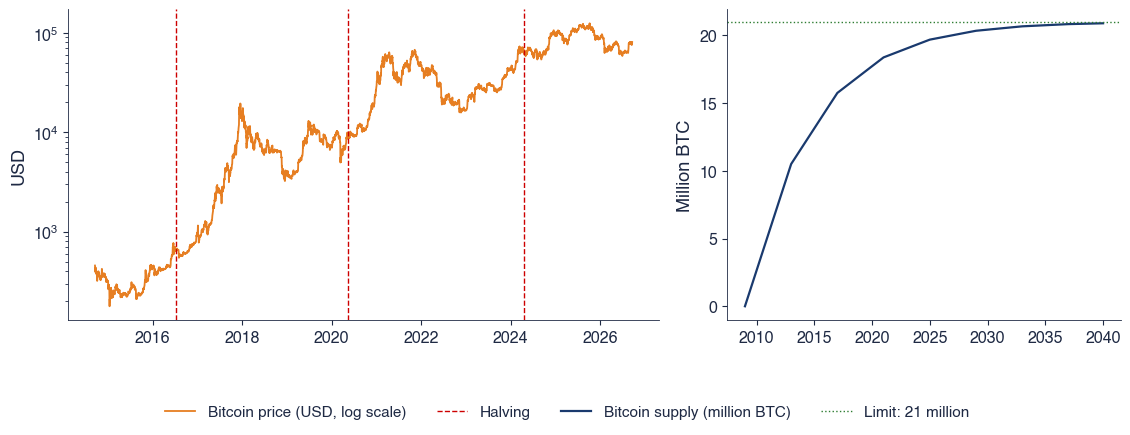

In [8]:
fig_halving(save=False)

## 2. Crypto as an asset class

- Moments, annualisation with the actual frequency and with 252 days, Hill tail indices ($k = 2.5\%$ of $n$).

In [9]:
T = {k: describe(k) for k in ASSETS}
pd.DataFrame(T).T[['n', 'mean', 'sd', 'skew', 'exkurt', 'ann_vol', 'ann_vol_252', 'hill_left', 'hill_left_lo', 'hill_left_hi', 'hill_right']].round(3)

,n,mean,sd,skew,exkurt,ann_vol,ann_vol_252,hill_left,hill_left_lo,hill_left_hi,hill_right
btc,4384,0.118056,3.485192,-0.704892,11.95772,66.614901,55.325711,2.706288,2.198226,3.21435,3.36793
eth,3913,0.202428,4.986115,-0.203963,8.978106,95.304391,79.152123,2.623359,2.10129,3.145428,3.091681
sol,2351,0.211671,6.12396,-0.218955,7.88839,117.063048,97.214848,2.841562,2.110256,3.572868,3.414097
sp500,3017,0.044443,1.110079,-0.636894,15.776163,17.60155,17.621958,2.684395,2.076859,3.291931,2.801042
gold,3124,0.04083,1.014933,-0.408813,9.485183,16.375789,16.111561,3.106476,2.417067,3.795885,3.036466


In [10]:
def fig_rolling_vol(save=True):
    """Volatility on rolling windows of about one month, annualised at the actual frequency: 30 daily returns
    times sqrt(365) for Bitcoin and Ethereum, 21 daily returns times sqrt(252) for the S&P 500."""
    fig, ax = plt.subplots(figsize=(11, 4.0))
    out = {}
    for k, w, ppy in [('btc', 30, 365), ('eth', 30, 365), ('sp500', 21, 252)]:
        r = returns(k, '2016-01-01')
        v = r.rolling(w).std() * np.sqrt(ppy)
        ax.plot(v.index, v.values, color=COLORS[k], lw=1.1, label=f'{NAME[k]} ({w} returns, x sqrt({ppy}))')
        v = v.dropna()
        out[k] = {'median': float(v.median()), 'max': float(v.max()), 'max_date': v.idxmax().date().isoformat(),
                  'last': float(v.iloc[-1]), 'min': float(v.min()), 'min_date': v.idxmin().date().isoformat()}
    ax.set_ylabel('Annualised volatility (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_rolling_vol')
    b, s = returns('btc', '2016-01-01').rolling(30).std() * np.sqrt(365), returns('sp500', '2016-01-01').rolling(21).std() * np.sqrt(252)
    j = pd.concat([b, s], axis=1).dropna()
    out['ratio_median'] = float((j.iloc[:, 0] / j.iloc[:, 1]).median())
    out['share_btc_below_sp'] = float(100 * np.mean(j.iloc[:, 0] < j.iloc[:, 1]))
    return out

{'btc': {'median': 53.75740719924252,
  'max': 198.02166509641572,
  'max_date': '2020-04-06',
  'last': 47.23238677189544,
  'min': 13.530605489212153,
  'min_date': '2016-04-17'},
 'eth': {'median': 77.27734540492766,
  'max': 241.4233095743482,
  'max_date': '2020-04-06',
  'last': 53.22929452154166,
  'min': 15.432344156193883,
  'min_date': '2023-08-13'},
 'sp500': {'median': 12.342527295918321,
  'max': 97.55516558037651,
  'max_date': '2020-04-06',
  'last': 9.630478801326651,
  'min': 3.4688266848221483,
  'min_date': '2017-10-11'},
 'ratio_median': 3.8118389122477083,
 'share_btc_below_sp': 0.11231748408835641}

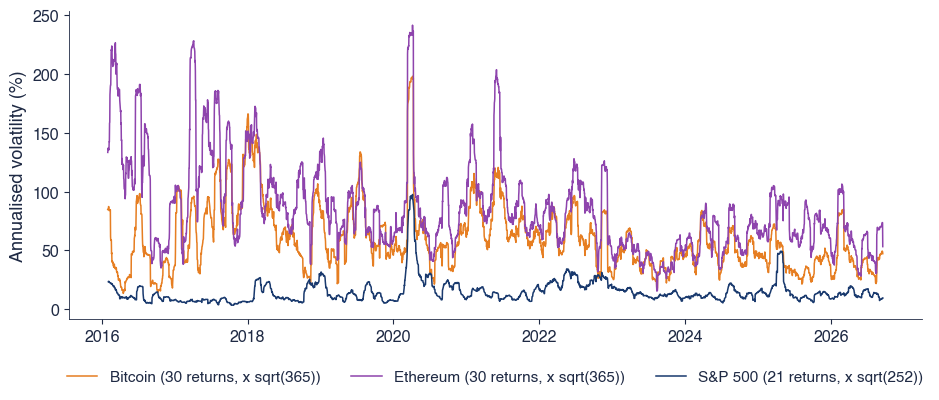

In [11]:
fig_rolling_vol(save=False)

## 3. The weekday effect

- Weekend dummy with HAC standard errors (mean); Brown–Forsythe test (variance).

In [12]:
def weekday_effect(k='btc', periods=WD_PERIODS):
    """Mean and standard deviation of daily returns by day of the week (the day of the closing price); the weekend
    dummy in r_t = a + b W_t + e_t with HAC standard errors; Brown-Forsythe test of equal variance on weekend and
    weekdays; the ratio of the weekend to the weekday variance."""
    out = {}
    for lab, (a, b) in periods.items():
        r = returns(k, a, b)
        d = pd.DataFrame({'r': r, 'dow': r.index.dayofweek})
        w = (d['dow'] >= 5).astype(float)
        reg = hac_ols(d['r'], w.rename('weekend'))
        bf = stats.levene(d.loc[w == 1, 'r'], d.loc[w == 0, 'r'], center='median')
        out[lab] = {'n': int(len(r)), 'mean': {DAYS[i]: float(g.mean()) for i, g in d.groupby('dow')['r']},
                    'sd': {DAYS[i]: float(g.std()) for i, g in d.groupby('dow')['r']},
                    'b': float(reg.params['weekend']), 't': float(reg.tvalues['weekend']), 'p': float(reg.pvalues['weekend']),
                    'bf': float(bf.statistic), 'p_bf': float(bf.pvalue),
                    'var_ratio': float(d.loc[w == 1, 'r'].var() / d.loc[w == 0, 'r'].var()),
                    'sd_we': float(d.loc[w == 1, 'r'].std()), 'sd_wd': float(d.loc[w == 0, 'r'].std())}
    return out


def fig_weekday(W=None, save=True):
    """Standard deviation of Bitcoin's daily returns by day of the week in three periods."""
    W = W or weekday_effect()
    fig, ax = plt.subplots(figsize=(10, 3.8))
    x = np.arange(7)
    cols = [st.MainBlue, st.Orange, st.IDAred]
    for i, (lab, d) in enumerate(W.items()):
        ax.bar(x + (i - 1) * 0.27, [d['sd'][day] for day in DAYS], width=0.27, color=cols[i], label=lab)
    ax.set_xticks(x)
    ax.set_xticklabels(DAYS)
    ax.set_ylabel('Std. dev. of daily returns (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_weekday')
    return W

,b,p,var ratio,p BF
2014-2019,-0.0110,0.9482,0.6563,0.0018
2020-2023,-0.1111,0.4755,0.3509,0.0000
2024-2026,-0.0316,0.8344,0.3895,0.0000


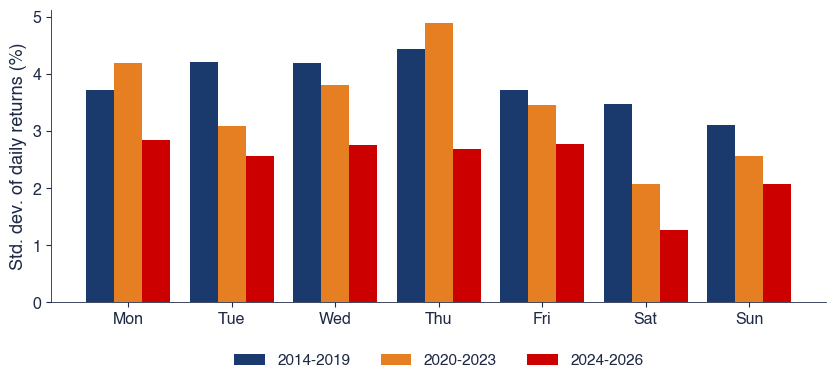

In [13]:
W = fig_weekday(save=False)
pd.DataFrame({k: {'b': v['b'], 'p': v['p'], 'var ratio': v['var_ratio'], 'p BF': v['p_bf']} for k, v in W.items()}).T.round(4)

## 4. Volatility clustering and GARCH(1,1)-t

- ACF of returns and squared returns; GARCH(1,1)-t and GJR for four assets.

In [14]:
def fig_acf(k='btc', nlags=30, save=True):
    """ACF of the returns and of the squared returns of Bitcoin, with the bands +-1.96/sqrt(n)."""
    r = returns(k).values
    n = len(r)
    a1, a2 = acf(r, nlags), acf(r ** 2, nlags)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
    lags = np.arange(1, nlags + 1)
    for ax, a, c, lab in [(axes[0], a1, st.MainBlue, 'ACF of returns'), (axes[1], a2, st.IDAred, 'ACF of squared returns')]:
        ax.bar(lags, a, color=c, width=0.6, label=lab)
        ax.axhline(1.96 / np.sqrt(n), color='black', lw=0.8, ls='--')
        ax.axhline(-1.96 / np.sqrt(n), color='black', lw=0.8, ls='--', label='_b')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel('Lag (days)')
    axes[0].plot([], [], color='black', ls='--', lw=0.8, label='+-1.96/sqrt(n)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_acf')
    out = {'n': n, 'rho1': float(a1[0]), 'rho1_sq': float(a2[0]), 'rho10_sq': float(a2[9]), 'band': float(1.96 / np.sqrt(n)),
           'n_out_r': int(np.sum(np.abs(a1) > 1.96 / np.sqrt(n))), 'n_out_sq': int(np.sum(np.abs(a2) > 1.96 / np.sqrt(n)))}
    out['lb_r'] = ljung_box(r)
    out['lb_sq'] = ljung_box(r ** 2)
    sp = returns('sp500').values
    out['sp_lb_r'] = ljung_box(sp)
    out['sp_lb_sq'] = ljung_box(sp ** 2)
    return out


def garch_table(names=('btc', 'eth', 'sp500', 'gold')):
    """GARCH(1,1)-t estimates, persistence alpha + beta, half-life ln(0.5)/ln(alpha + beta) of a volatility shock,
    the unconditional volatility annualised at the actual frequency; GJR asymmetry gamma and its t-statistic."""
    out = {}
    for k in names:
        r = returns(k)
        ppy = periods_per_year(r)
        res = garch_fit(r)
        p, t = res.params, res.tvalues
        a, b = float(p['alpha[1]']), float(p['beta[1]'])
        pers = a + b
        gj = garch_fit(r, o=1)
        sig = res.conditional_volatility
        out[k] = {'n': int(len(r)), 'mu': float(p['mu']), 'omega': float(p['omega']), 'alpha': a, 'beta': b,
                  'nu': float(p['nu']), 't_alpha': float(t['alpha[1]']), 't_beta': float(t['beta[1]']),
                  'pers': pers, 'ppy': float(ppy),
                  # alpha + beta = 1 (integrated GARCH): no finite half-life, no unconditional variance
                  'half_life': float(np.log(0.5) / np.log(pers)) if pers < 0.9999 else None,
                  'uncond_ann': float(np.sqrt(ppy * p['omega'] / (1 - pers))) if pers < 0.9999 else None,
                  'gamma': float(gj.params['gamma[1]']), 't_gamma': float(gj.tvalues['gamma[1]']),
                  'p_gamma': float(gj.pvalues['gamma[1]']), 'sig_last': float(sig.iloc[-1] * np.sqrt(ppy)),
                  'sig_max': float(sig.max() * np.sqrt(ppy)), 'sig_max_date': sig.idxmax().date().isoformat(),
                  'loglik': float(res.loglikelihood)}
    return out


def fig_garch_vol(save=True):
    """Conditional volatility of GARCH(1,1)-t, annualised at the actual frequency: Bitcoin and the S&P 500."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    for k in ('btc', 'sp500'):
        r = returns(k)
        s = garch_fit(r).conditional_volatility * np.sqrt(periods_per_year(r))
        ax.plot(s.index, s.values, color=COLORS[k], lw=1.1, label=f'{NAME[k]}: GARCH(1,1)-t volatility (annualised)')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_garch_vol')

{'n': 4384,
 'rho1': -0.02230531534360892,
 'rho1_sq': 0.13668910961302372,
 'rho10_sq': 0.039099015298861034,
 'band': 0.02960198257317867,
 'n_out_r': 4,
 'n_out_sq': 15,
 'lb_r': {'q': 20.17834764721007, 'p': 0.027610237899489007},
 'lb_sq': {'q': 212.74453467796116, 'p': 3.521253727538104e-40},
 'sp_lb_r': {'q': 236.08108476597627, 'p': 4.554052914463274e-45},
 'sp_lb_sq': {'q': 3241.783455467711, 'p': 0.0}}

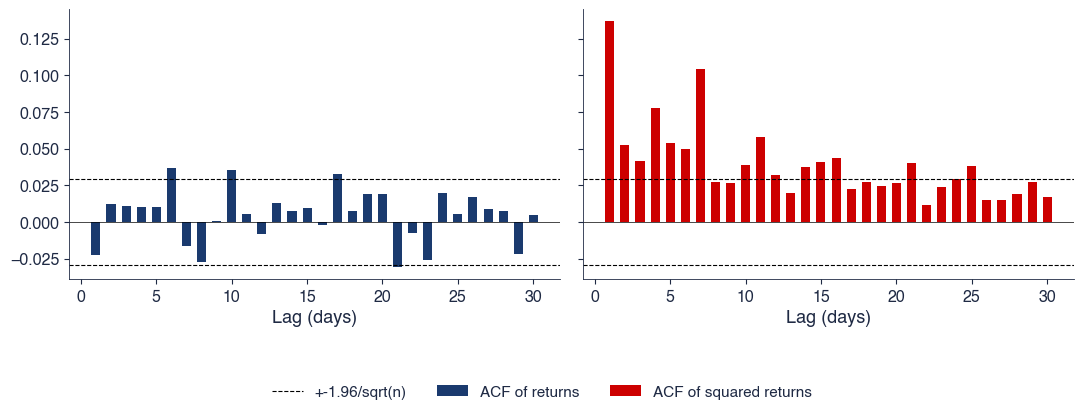

In [15]:
fig_acf(save=False)

In [16]:
G = garch_table()
pd.DataFrame(G).T[['omega', 'alpha', 'beta', 'pers', 'half_life', 'nu', 'gamma', 't_gamma']].round(3)

,omega,alpha,beta,pers,half_life,nu,gamma,t_gamma
btc,0.193692,0.108737,0.891263,1.0,None,3.180637,-0.013471,-0.720778
eth,1.067294,0.174741,0.825259,1.0,None,3.144253,0.03172,0.913646
sp500,0.02368,0.173043,0.82006,0.993103,100.146056,5.499756,0.279662,7.084556
gold,0.010085,0.046925,0.946943,0.993868,112.694043,4.130748,-0.051388,-3.328091


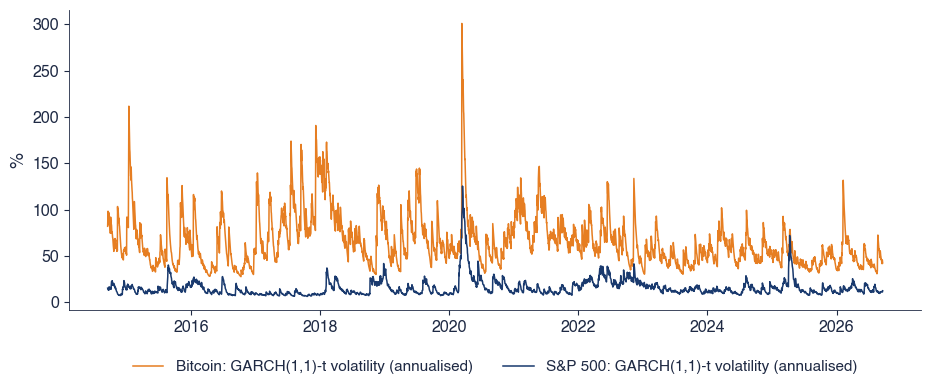

In [17]:
fig_garch_vol(save=False)

## 5. Weak-form efficiency: variance ratios

- Lo–MacKinlay VR(q) with the robust $Z^*(q)$; sub-periods; rolling windows of 500 observations.

In [18]:
def variance_ratio(x, q):
    """Lo and MacKinlay (1988): overlapping VR(q), the homoskedastic Z(q) and the heteroskedasticity-robust Z*(q)
    (Chapter 7)."""
    x = np.asarray(x, float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = np.sum(e ** 2) / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu
    m = q * (T - q + 1) * (1 - q / T)
    vr = (np.sum(agg ** 2) / m) / var_a
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = np.sum(e ** 2) ** 2
    theta = sum((2 * (q - j) / q) ** 2 * T * np.sum(e[j:] ** 2 * e[:-j] ** 2) / den for j in range(1, q))
    zs = (vr - 1) / np.sqrt(theta / T)
    return {'q': q, 'vr': float(vr), 'z': float(z), 'zs': float(zs), 'p': float(2 * stats.norm.sf(abs(zs)))}


def efficiency_table(names=('btc', 'eth', 'sp500')):
    """Whole sample: rho_hat(1), Ljung-Box Q(10), VR(q) and Z*(q) for q = 2, 5, 10; the same by sub-period."""
    out = {}
    for k in names:
        r = returns(k).values
        out[k] = {'n': len(r), 'rho1': float(acf(r, 1)[0]), 'lb': ljung_box(r),
                  'vr': {str(q): variance_ratio(r, q) for q in VR_Q}}
        out[k]['sub'] = {}
        for a, b in SUBPERIODS:
            if pd.Timestamp(a) < pd.Timestamp(START[k]):
                a = START[k]
            x = returns(k, a, b).values
            out[k]['sub'][a[:4] + '-' + b[:4]] = {'n': len(x), 'rho1': float(acf(x, 1)[0]),
                                                 'vr5': variance_ratio(x, 5), 'vr2': variance_ratio(x, 2)}
    return out


def rolling_vr(k, q=5, window=VR_WINDOW, step=VR_STEP):
    """VR(q) and Z*(q) on rolling windows of `window` observations, one every `step` observations."""
    r = returns(k)
    x = r.values
    rows = []
    for e in range(window, len(x) + 1, step):
        v = variance_ratio(x[e - window:e], q)
        rows.append((r.index[e - 1], v['vr'], v['z'], v['zs']))
    return pd.DataFrame(rows, columns=['date', 'vr', 'z', 'zs']).set_index('date')


def fig_rolling_vr(names=('btc', 'eth', 'sp500'), q=5, save=True):
    """Rolling robust Z*(5) of the variance-ratio test on windows of 500 observations."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    out = {}
    for k in names:
        d = rolling_vr(k, q)
        ax.plot(d.index, d['zs'], color=COLORS[k], lw=1.2, label=NAME[k])
        early = d.loc[:'2018-12-31']
        late = d.loc['2019-01-01':]
        out[k] = {'n_win': len(d), 'share_rej': float(100 * np.mean(np.abs(d['zs']) > 1.96)),
                  'share_rej_iid': float(100 * np.mean(np.abs(d['z']) > 1.96)),
                  'vr_min': float(d['vr'].min()), 'vr_max': float(d['vr'].max()),
                  'share_rej_early': float(100 * np.mean(np.abs(early['zs']) > 1.96)) if len(early) else None,
                  'share_rej_late': float(100 * np.mean(np.abs(late['zs']) > 1.96)),
                  'min': float(d['zs'].min()), 'min_date': d['zs'].idxmin().date().isoformat(),
                  'last': float(d['zs'].iloc[-1]), 'first': d.index[0].date().isoformat()}
    ax.axhline(1.96, color='black', lw=0.8, ls='--', label='+-1.96')
    ax.axhline(-1.96, color='black', lw=0.8, ls='--', label='_b')
    ax.set_ylabel(f'Robust Z*({q})')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_rolling_vr')
    return out

In [19]:
E = efficiency_table()
pd.DataFrame({k: {f'VR({q})': v['vr'] for q, v in e['vr'].items()} | {f'Z*({q})': v['zs'] for q, v in e['vr'].items()} for k, e in E.items()}).T.round(3)

,VR(2),VR(5),VR(10),Z*(2),Z*(5),Z*(10)
btc,0.977,0.991,1.027,-0.883,-0.185,0.371
eth,0.988,1.067,1.137,-0.429,1.174,1.639
sp500,0.875,0.849,0.813,-2.298,-1.280,-1.084


{'btc': {'n_win': 185,
  'share_rej': 0.0,
  'share_rej_iid': 1.6216216216216217,
  'vr_min': 0.7811067061855379,
  'vr_max': 1.167454318718109,
  'share_rej_early': 0.0,
  'share_rej_late': 0.0,
  'min': -1.4539549021812994,
  'min_date': '2026-04-04',
  'last': 0.133047260506208,
  'first': '2016-01-30'},
 'eth': {'n_win': 163,
  'share_rej': 0.0,
  'share_rej_iid': 0.0,
  'vr_min': 0.850200140195423,
  'vr_max': 1.1756927057058206,
  'share_rej_early': 0.0,
  'share_rej_late': 0.0,
  'min': -1.3917305280111687,
  'min_date': '2024-05-20',
  'last': 0.43054902684617163,
  'first': '2017-05-15'},
 'sp500': {'n_win': 120,
  'share_rej': 0.0,
  'share_rej_iid': 21.666666666666668,
  'vr_min': 0.7007231426505481,
  'vr_max': 1.009306279567891,
  'share_rej_early': 0.0,
  'share_rej_late': 0.0,
  'min': -1.7350408146904062,
  'min_date': '2022-03-16',
  'last': -0.7089199522305141,
  'first': '2016-09-12'}}

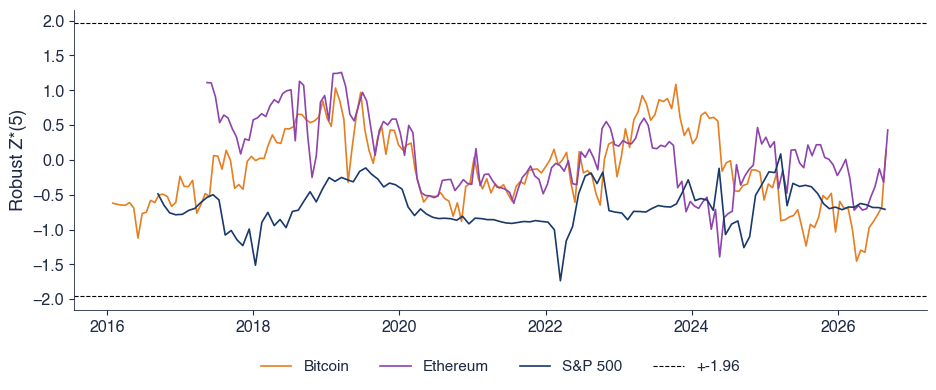

In [20]:
fig_rolling_vr(save=False)

## 6. Correlation with equities and gold

- Rolling 250-day correlation; crisis episodes; returns on the worst 5% of S&P 500 days.

In [21]:
def fig_rolling_corr(save=True):
    """Rolling 250-day correlation of daily log returns (prices joined on common days): Bitcoin with the S&P 500,
    Bitcoin with gold, Ethereum with the S&P 500; the crisis and ETF dates."""
    pairs = [('btc', 'sp500'), ('btc', 'gold'), ('eth', 'sp500')]
    cols = [st.MainBlue, st.Amber, st.Purple]
    fig, ax = plt.subplots(figsize=(11, 4.0))
    out = {}
    for (a, b), c in zip(pairs, cols):
        R = joint_returns(a, b)
        rc = R[a].rolling(CORR_WINDOW).corr(R[b]).dropna()
        ax.plot(rc.index, rc.values, color=c, lw=1.3, label=f'{NAME[a]} and {NAME[b]}')
        yr = R.groupby(R.index.year).apply(lambda g: g[a].corr(g[b]))
        wk = pd.concat([close(a), close(b)], axis=1).dropna().resample('W-FRI').last()
        wr = np.log(wk).diff().dropna()
        out[f'{a}_{b}'] = {'n': int(len(R)), 'all': float(R[a].corr(R[b])), 'weekly': float(wr[a].corr(wr[b])),
                           'pre2020': float(R.loc[:'2019-12-31', a].corr(R.loc[:'2019-12-31', b])),
                           'post2020': float(R.loc['2020-01-01':, a].corr(R.loc['2020-01-01':, b])),
                           'year': {str(y): float(v) for y, v in yr.items()},
                           'max': float(rc.max()), 'max_date': rc.idxmax().date().isoformat(),
                           'min': float(rc.min()), 'min_date': rc.idxmin().date().isoformat(), 'last': float(rc.iloc[-1])}
    ev_cols = [st.IDAred, st.Crimson, st.Orange, st.Forest]
    for (lab, d), c in zip(EVENTS.items(), ev_cols):
        ax.axvline(pd.Timestamp(d), color=c, lw=1.0, ls='--', label=lab)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_ylabel('Correlation (250 common days)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_rolling_corr')
    return out


def crisis_table(episodes=EPISODES):
    """Cumulative log return (in %) from the close of the first day to the close of the last day of each episode;
    Bitcoin's worst day in the episode."""
    out = {}
    for lab, (a, b) in episodes.items():
        row = {}
        for k in ('btc', 'eth', 'sp500', 'gold'):
            p = close(k, '2014-01-01')
            p0 = p.loc[:a].iloc[-1]
            p1 = p.loc[:b].iloc[-1]
            row[k] = float(100 * np.log(p1 / p0))
        r = returns('btc', a, b)
        row['btc_worst'] = float(r.min())
        row['btc_worst_date'] = r.idxmin().date().isoformat()
        row['start'], row['end'] = a, b
        out[lab] = row
    return out


def worst_days(q=0.05):
    """Mean returns of Bitcoin and gold on the S&P 500's worst 5% of days (prices joined on common days) and their
    correlation with the S&P 500 on those days (Baur and Lucey, 2010: hedge and safe haven)."""
    out = {}
    for k in ('btc', 'gold'):
        R = joint_returns(k, 'sp500')
        thr = R['sp500'].quantile(q)
        bad = R[R['sp500'] <= thr]
        t = stats.ttest_1samp(bad[k], 0.0)
        out[k] = {'n': int(len(R)), 'n_bad': int(len(bad)), 'thr': float(thr), 'mean_sp': float(bad['sp500'].mean()),
                  'mean': float(bad[k].mean()), 't': float(t.statistic), 'p': float(t.pvalue),
                  'mean_all': float(R[k].mean()), 'corr_bad': float(bad[k].corr(bad['sp500'])),
                  'share_neg': float(100 * np.mean(bad[k] < 0))}
    return out

,all,weekly,pre2020,post2020
btc_sp500,0.237,0.186,0.018,0.389
btc_gold,0.085,0.097,-0.010,0.150
eth_sp500,0.246,0.244,0.016,0.401


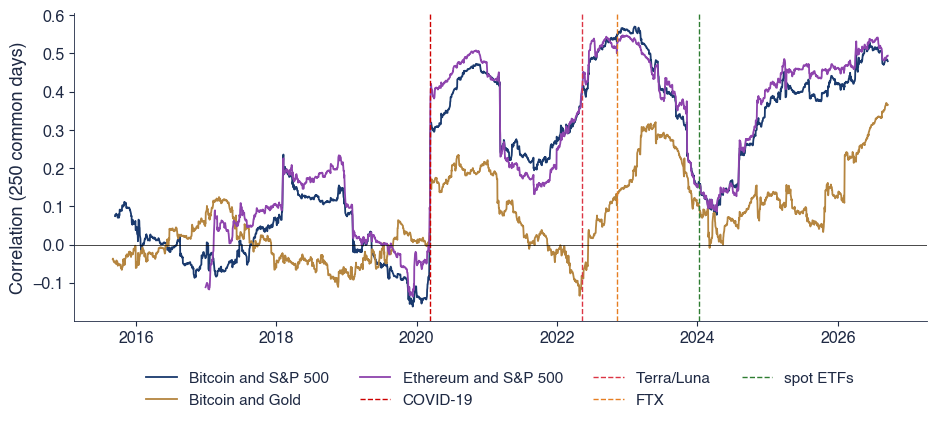

In [22]:
C = fig_rolling_corr(save=False)
pd.DataFrame({k: {c: v[c] for c in ['all', 'weekly', 'pre2020', 'post2020']} for k, v in C.items()}).T.round(3)

In [23]:
pd.DataFrame(crisis_table()).T

,btc,eth,sp500,gold,btc_worst,btc_worst_date,start,end
COVID-19,-40.639094,-65.515354,-41.437912,0.260298,-46.473021,2020-03-12,2020-02-19,2020-03-23
Terra/Luna,-23.042777,-33.750245,-5.369405,-2.980883,-11.705491,2022-05-09,2022-05-05,2022-05-12
FTX,-29.868932,-38.445748,4.647948,3.367011,-15.488959,2022-11-09,2022-11-05,2022-11-21


In [24]:
worst_days()

{'btc': {'n': 3017,
  'n_bad': 151,
  'thr': -1.6496298895573958,
  'mean_sp': -2.7048000328953288,
  'mean': -2.7716111665604517,
  't': -4.888948396899757,
  'p': 2.5807703921895517e-06,
  'mean_all': 0.17154700535422365,
  'corr_bad': 0.36310698739738284,
  'share_neg': 70.19867549668875},
 'gold': {'n': 3016,
  'n_bad': 151,
  'thr': -1.6498837676056644,
  'mean_sp': -2.7048000328953288,
  'mean': 0.09890058471388165,
  't': 0.8551399750330221,
  'p': 0.39383746768699657,
  'mean_all': 0.04229242921020154,
  'corr_bad': 0.2088266206493575,
  'share_neg': 45.033112582781456}}

## 7. Drawdowns and the spot Bitcoin ETFs

In [25]:
def drawdown(p):
    """Drawdown D_t = P_t / max_{s <= t} P_s - 1 (in %)."""
    return 100 * (p / p.cummax() - 1)


def drawdown_episodes(p, depth=-50.0):
    """Episodes between two record highs whose deepest drawdown is below `depth` %: peak, trough, recovery."""
    dd = drawdown(p)
    out = []
    peak_date = p.index[0]
    i = 0
    vals = dd.values
    idx = dd.index
    while i < len(vals):
        if vals[i] < 0:
            j = i
            while j < len(vals) and vals[j] < 0:
                j += 1
            seg = dd.iloc[i:j]
            if seg.min() <= depth:
                tr = seg.idxmin()
                out.append({'peak': idx[i - 1].date().isoformat() if i > 0 else idx[0].date().isoformat(),
                            'peak_price': float(p.iloc[i - 1] if i > 0 else p.iloc[0]),
                            'trough': tr.date().isoformat(), 'trough_price': float(p.loc[tr]),
                            'depth': float(seg.min()),
                            'recovery': idx[j].date().isoformat() if j < len(vals) else None,
                            'days_down': int((tr - idx[max(i - 1, 0)]).days),
                            'days_under': int((idx[j] - idx[max(i - 1, 0)]).days) if j < len(vals) else None})
            i = j
        else:
            i += 1
    return out


def fig_drawdowns(save=True):
    """Drawdowns of Bitcoin, Ethereum and the S&P 500 since 2016."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    out = {}
    for k in ('btc', 'eth', 'sp500'):
        p = close(k, '2016-01-01')
        dd = drawdown(p)
        ax.plot(dd.index, dd.values, color=COLORS[k], lw=1.1, label=NAME[k])
        out[k] = {'mdd': float(dd.min()), 'mdd_date': dd.idxmin().date().isoformat(), 'last': float(dd.iloc[-1]),
                  'share_10': float(100 * np.mean(dd < -10))}
    ax.set_ylabel('Drawdown (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_drawdowns')
    out['btc_episodes'] = drawdown_episodes(close('btc'))
    return out


def etf_effect(before=('2022-01-11', '2024-01-10'), after=('2024-01-11', '2026-01-10')):
    """Bitcoin two years before and two years after the launch of the US spot ETFs: annualised volatility, the
    Brown-Forsythe test of equal variance, the weekend share of variance, the correlation with the S&P 500."""
    out = {}
    rb, ra = returns('btc', *before), returns('btc', *after)
    bf = stats.levene(rb, ra, center='median')
    out['vol_before'] = float(rb.std() * np.sqrt(365))
    out['vol_after'] = float(ra.std() * np.sqrt(365))
    out['bf'], out['p_bf'] = float(bf.statistic), float(bf.pvalue)
    out['n_before'], out['n_after'] = int(len(rb)), int(len(ra))
    for lab, (a, b) in (('before', before), ('after', after)):
        r = returns('btc', a, b)
        w = r.index.dayofweek >= 5
        out[f'we_ratio_{lab}'] = float(r[w].var() / r[~w].var())
        out[f'we_share_{lab}'] = float(100 * np.sum(r[w] ** 2) / np.sum(r ** 2))
        R = joint_returns('btc', 'sp500', a, b)
        out[f'corr_{lab}'] = float(R['btc'].corr(R['sp500']))
        g = garch_fit(r)
        out[f'pers_{lab}'] = float(g.params['alpha[1]'] + g.params['beta[1]'])
    # IBIT against Bitcoin, prices joined on the ETF's trading days
    R = joint_returns('ibit', 'btc', ETF_DATE)
    beta = np.polyfit(R['btc'], R['ibit'], 1)[0]
    out['ibit'] = {'n': int(len(R)), 'corr': float(R['ibit'].corr(R['btc'])), 'beta': float(beta),
                   'te': float((R['ibit'] - R['btc']).std() * np.sqrt(252)),
                   'vol_ibit': float(R['ibit'].std() * np.sqrt(252)), 'vol_btc_same': float(R['btc'].std() * np.sqrt(252))}
    return out


def fig_etf(save=True):
    """Left: Bitcoin volatility on 90-day rolling windows (x sqrt(365)) with the ETF launch. Right: weekend share of
    the squared returns by year (2/7 = 28.6% if every day had the same variance)."""
    r = returns('btc')
    v = (r.rolling(90).std() * np.sqrt(365)).loc['2020-01-01':]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(v.index, v.values, color=COLORS['btc'], lw=1.3, label='Bitcoin volatility, 90-day window (annualised, %)')
    axes[0].axvline(pd.Timestamp(ETF_DATE), color=st.IDAred, lw=1.2, ls='--', label='Spot ETFs: 11 Jan 2024')
    w = r.index.dayofweek >= 5
    sh = (r[w] ** 2).groupby(r[w].index.year).sum() / (r ** 2).groupby(r.index.year).sum() * 100
    sh = sh.loc[2015:]
    axes[1].bar(sh.index.astype(str), sh.values, color=st.MainBlue, label='Weekend share of squared returns (%)')
    axes[1].axhline(200 / 7, color=st.Forest, lw=1.2, ls='--', label='2/7 of the days')
    axes[1].tick_params(axis='x', rotation=60, labelsize=9)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_etf')
    return {'we_share_year': {str(y): float(x) for y, x in sh.items()}}

,peak,peak_price,trough,trough_price,depth,recovery,days_down,days_under
0,2014-09-17,457.334015,2015-01-14,178.102997,-61.056254,2015-12-15,119,454.0
1,2017-12-16,19497.400391,2018-12-15,3236.761645,-83.399009,2020-11-30,364,1080.0
2,2021-04-13,63503.457930,2021-07-20,29807.347673,-53.061851,2021-10-19,98,189.0
3,2021-11-08,67566.830088,2022-11-21,15787.284095,-76.634565,2024-03-04,378,847.0
4,2025-10-06,124752.528352,2026-06-30,58558.859375,-53.059982,None,267,NaN


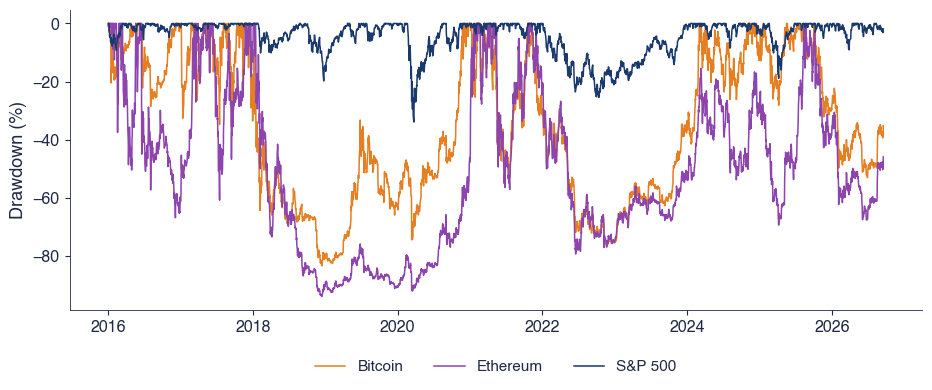

In [26]:
D = fig_drawdowns(save=False)
pd.DataFrame(D['btc_episodes'])

In [27]:
etf_effect()

{'vol_before': 55.17156826841956,
 'vol_after': 47.470994725835006,
 'bf': 1.218956270151776,
 'p_bf': 0.2697478837763787,
 'n_before': 729,
 'n_after': 730,
 'we_ratio_before': 0.30369570704844034,
 'we_share_before': 10.785311863499219,
 'corr_before': 0.44703155253697435,
 'pers_before': 1.000000000000131,
 'we_ratio_after': 0.4193980416919,
 'we_share_after': 14.393819098950182,
 'corr_after': 0.36835108481999135,
 'pers_after': 0.9743698245159932,
 'ibit': {'n': 671,
  'corr': 0.9089691718185607,
  'beta': 0.9355909015387577,
  'te': 20.753134171910173,
  'vol_ibit': 49.23241785868116,
  'vol_btc_same': 47.83153621313498}}

{'we_share_year': {'2015': 20.90636815362793,
  '2016': 26.498642077286206,
  '2017': 19.39511778365012,
  '2018': 18.181263873555846,
  '2019': 22.79615136068467,
  '2020': 11.741766904367648,
  '2021': 14.043613937015628,
  '2022': 10.904655470310516,
  '2023': 11.258747061848355,
  '2024': 11.061101450957505,
  '2025': 19.036897861297504,
  '2026': 11.103952744605344}}

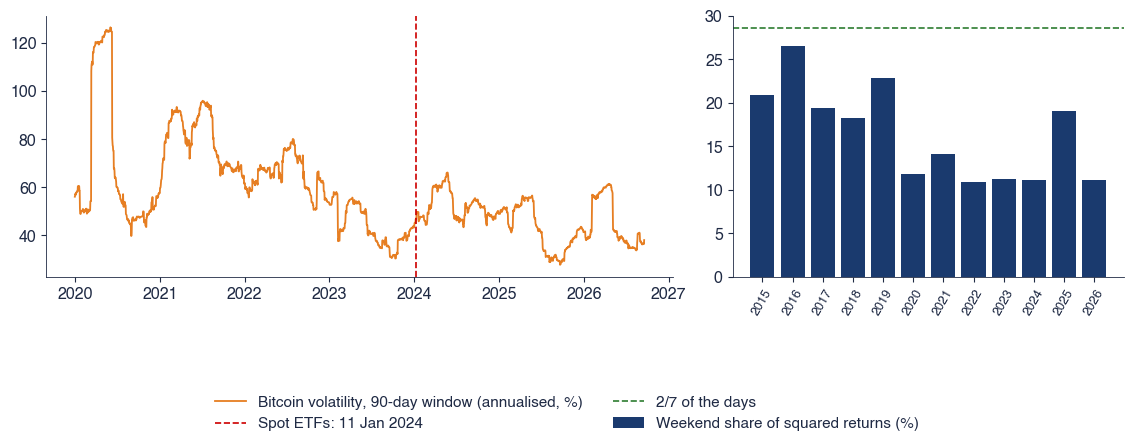

In [28]:
fig_etf(save=False)

## 8. Stablecoins

- Supply (DefiLlama), peg deviations, March 2023, TerraUSD.

In [29]:
def stablecoin_chart(sid=None):
    """DefiLlama: circulating supply of USD stablecoins, billion USD (sid=None: all; 1 USDT, 2 USDC, 3 UST, 5 DAI);
    columns 'supply' (billion units) and 'value' (billion USD)."""
    if sid in _LLAMA:
        return _LLAMA[sid]
    url = LLAMA + (f'?stablecoin={sid}' if sid else '')
    js = json.loads(urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                           timeout=120).read())
    rows = {}
    for x in js:
        d = pd.Timestamp(int(x['date']), unit='s').normalize()
        c = (x.get('totalCirculating') or {}).get('peggedUSD')
        v = (x.get('totalCirculatingUSD') or {}).get('peggedUSD')
        if c is not None:
            rows[d] = (c / 1e9, (v if v is not None else np.nan) / 1e9)
    df = pd.DataFrame(rows, index=['supply', 'value']).T.sort_index().loc[:END]
    _LLAMA[sid] = df
    return df


def stablecoin_prices(coin='terrausd', start='2022-04-01', end='2022-06-30'):
    """DefiLlama: daily USD price of one stablecoin (key of the 'prices' dictionary, e.g. 'terrausd')."""
    key = ('prices', coin)
    if key not in _LLAMA:
        js = json.loads(urllib.request.urlopen(urllib.request.Request(
            'https://stablecoins.llama.fi/stablecoinprices', headers={'User-Agent': 'Mozilla'}), timeout=120).read())
        s = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['prices'][coin]
                       for x in js if coin in (x.get('prices') or {})}).sort_index()
        _LLAMA[key] = s
    return _LLAMA[key].loc[start:end]


def fig_stablecoin_supply(save=True):
    """Supply of USD stablecoins (DefiLlama): total, USDT, USDC, DAI, billion USD."""
    tot = stablecoin_chart()['value'].loc['2019-01-01':]
    parts = {k: stablecoin_chart(STABLE_ID[k])['value'].loc['2019-01-01':] for k in ('usdt', 'usdc', 'dai')}
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(tot.index, tot.values, color=COLORS['total'], lw=1.5, label='All USD stablecoins')
    for k, s in parts.items():
        ax.plot(s.index, s.values, color=COLORS[k], lw=1.2, label=NAME[k])
    ax.set_ylabel('Supply (USD bn)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_stablecoin_supply')
    lst = json.loads(urllib.request.urlopen(urllib.request.Request(
        'https://stablecoins.llama.fi/stablecoins?includePrices=false', headers={'User-Agent': 'Mozilla'}), timeout=120).read())
    mech = {}
    for x in lst['peggedAssets']:
        if x.get('pegType') == 'peggedUSD':
            m = (x.get('pegMechanism') or 'other').replace('crytpo', 'crypto')
            mech[m] = mech.get(m, 0) + ((x.get('circulating') or {}).get('peggedUSD') or 0) / 1e9
    end = tot.iloc[-1]
    y = lambda s, d: float(s.loc[:d].iloc[-1])   # noqa: E731
    return {'total_end': float(end), 'end': tot.index[-1].date().isoformat(), 'total_2020': y(tot, '2020-01-01'),
            'total_2022max': float(tot.loc[:'2022-12-31'].max()), 'total_2022max_date': tot.loc[:'2022-12-31'].idxmax().date().isoformat(),
            'total_trough': float(tot.loc['2022-06-01':'2024-06-30'].min()),
            'total_trough_date': tot.loc['2022-06-01':'2024-06-30'].idxmin().date().isoformat(),
            'usdt_end': float(parts['usdt'].iloc[-1]), 'usdc_end': float(parts['usdc'].iloc[-1]), 'dai_end': float(parts['dai'].iloc[-1]),
            'usdt_share': float(100 * parts['usdt'].iloc[-1] / end), 'usdc_share': float(100 * parts['usdc'].iloc[-1] / end),
            'usdc_2023_03_10': y(parts['usdc'], '2023-03-10'), 'usdc_2023_12_31': y(parts['usdc'], '2023-12-31'),
            'growth_x': float(end / y(tot, '2020-01-01')), 'mech_today': {k: float(v) for k, v in mech.items()}}


def peg_stats(k, start=PEG_START, end=END):
    """Peg deviation in basis points, d_t = 10 000 (P_t - 1), on daily closes and daily lows; AR(1) coefficient of
    the closing deviation and the half-life ln(0.5)/ln(phi) of a deviation."""
    register_extra()
    d = read_market(SERIES[k][0]).loc[start:end]
    dev = 1e4 * (d['close'] - 1)
    low = 1e4 * (d['low'] - 1)
    x = dev.values
    phi = np.corrcoef(x[1:], x[:-1])[0, 1]
    return {'n': int(len(dev)), 'mean': float(dev.mean()), 'sd': float(dev.std()), 'mad': float(np.median(np.abs(dev))),
            'gt10': float(100 * np.mean(np.abs(dev) > 10)), 'gt50': float(100 * np.mean(np.abs(dev) > 50)),
            'gt100': float(100 * np.mean(np.abs(dev) > 100)), 'close_min': float(dev.min()),
            'close_min_date': dev.idxmin().date().isoformat(), 'close_max': float(dev.max()),
            'close_max_date': dev.idxmax().date().isoformat(), 'low_min': float(low.min()),
            'low_min_date': low.idxmin().date().isoformat(), 'phi': float(phi),
            'half_life': float(np.log(0.5) / np.log(abs(phi)))}


def fig_peg(save=True):
    """Daily closing deviation from 1 USD (basis points) of USDT, USDC and DAI since 2021."""
    fig, axes = plt.subplots(3, 1, figsize=(11, 5.4), sharex=True)
    out = {}
    register_extra()
    for ax, k in zip(axes, ('usdt', 'usdc', 'dai')):
        d = read_market(SERIES[k][0]).loc[PEG_START:END]
        dev = 1e4 * (d['close'] - 1)
        ax.plot(dev.index, dev.clip(lower=-400).values, color=COLORS[k], lw=0.9, label=f'{NAME[k]}: close')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_ylim(-310, 130)
        ax.set_ylabel('bp')
        out[k] = peg_stats(k)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_peg')
    return out


def fig_svb(save=True):
    """March 2023: USDC and DAI below the peg after the closure of Silicon Valley Bank (10 March); daily closes and
    lows; USDT for comparison."""
    register_extra()
    a, b = SVB
    fig, ax = plt.subplots(figsize=(11, 3.9))
    out = {}
    for k in ('usdc', 'dai', 'usdt'):
        d = read_market(SERIES[k][0]).loc[a:b]
        ax.plot(d.index, d['close'], 'o-', color=COLORS[k], ms=4, lw=1.3, label=f'{NAME[k]}: close')
        ax.plot(d.index, d['low'], 'v', color=COLORS[k], ms=6, label=f'{NAME[k]}: daily low')
        out[k] = {'low': float(d['low'].min()), 'low_date': d['low'].idxmin().date().isoformat(),
                  'close_min': float(d['close'].min()), 'close_min_date': d['close'].idxmin().date().isoformat(),
                  'close_max': float(d['close'].max()), 'close_max_date': d['close'].idxmax().date().isoformat(),
                  'closes': {i.date().isoformat(): float(v) for i, v in d['close'].items()}}
    ax.axhline(1, color='black', lw=0.7, ls='--')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_svb')
    return out


def fig_ust(save=True):
    """TerraUSD (UST), April-June 2022 (DefiLlama): circulating supply (until the last published day) and price."""
    u = stablecoin_chart(STABLE_ID['ust']).loc['2022-04-01':'2022-06-15']
    u = u[u['supply'] > 0]['supply']
    px = stablecoin_prices('terrausd', '2022-04-01', '2022-06-15')
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
    axes[0].plot(u.index, u.values, 'o-', color=st.MainBlue, ms=2.5, lw=1.4, label='UST supply (billion)')
    axes[0].set_ylabel('Billion UST')
    axes[1].plot(px.index, px.values, 'o-', color=st.IDAred, ms=2.5, lw=1.2, label='UST price (USD)')
    axes[1].axhline(1, color='black', lw=0.7, ls='--')
    axes[1].set_ylabel('USD')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.tick_params(axis='x', labelsize=10, rotation=30)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_ust')
    pre = px.loc[:'2022-05-07']
    return {'supply_peak': float(u.max()), 'supply_peak_date': u.idxmax().date().isoformat(),
            'supply_last': float(u.iloc[-1]), 'last_date': u.index[-1].date().isoformat(),
            'supply_drop': float(100 * (1 - u.iloc[-1] / u.max())),
            'px_pre_min': float(pre.min()), 'px_pre_max': float(pre.max()),
            'px_0509': float(px.loc['2022-05-09']), 'px_0513': float(px.loc['2022-05-13']),
            'px_0514': float(px.loc['2022-05-14']), 'px_0531': float(px.loc['2022-05-31']),
            'px_end': float(px.iloc[-1]), 'px_end_date': px.index[-1].date().isoformat()}

{'total_end': 308.019607521,
 'end': '2026-09-18',
 'total_2020': 4.171183915,
 'total_2022max': 187.391942652,
 'total_2022max_date': '2022-04-02',
 'total_trough': 122.660540921,
 'total_trough_date': '2023-08-19',
 'usdt_end': 183.32932036,
 'usdc_end': 73.916109054,
 'dai_end': 4.771140262,
 'usdt_share': 59.51871760225558,
 'usdc_share': 23.997209024740606,
 'usdc_2023_03_10': 43.1760447,
 'usdc_2023_12_31': 24.014669037,
 'growth_x': 73.84464789800572,
 'mech_today': {'fiat-backed': 285.40547290514945,
  'crypto-backed': 27.100706947534448,
  'algorithmic': 0.26389971809156326}}

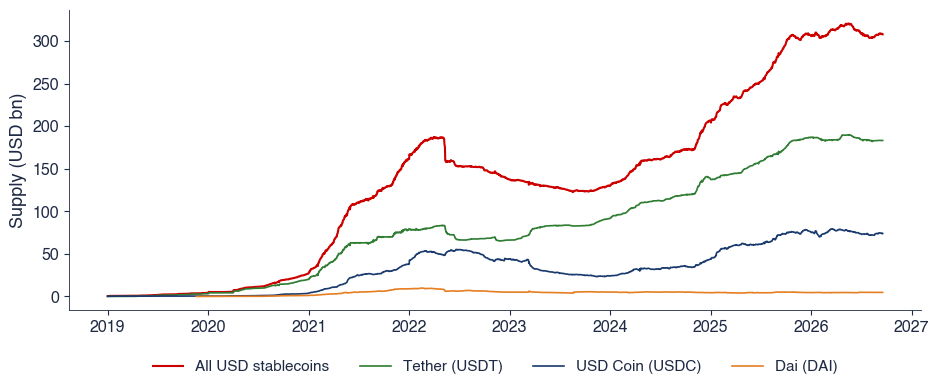

In [30]:
fig_stablecoin_supply(save=False)

,n,mean,sd,mad,gt10,gt50,gt100,close_min,close_min_date,close_max,close_max_date,low_min,low_min_date,phi,half_life
usdt,2087,0.583089,7.287367,3.081398,11.403929,0.143747,0.047916,-41.278609,2022-05-11,115.2966,2021-04-17,-515.138921,2022-05-12,0.726335,2.167824
usdc,2087,-0.210241,7.482593,1.126255,1.533301,0.143747,0.095831,-285.0,2023-03-11,104.9621,2021-04-17,-1226.0,2023-03-11,0.290163,0.560204
dai,2087,0.425141,10.83264,2.212519,10.685194,0.574988,0.143747,-261.31348,2023-03-11,103.104,2021-04-17,-1029.967719,2023-03-11,0.334916,0.633662


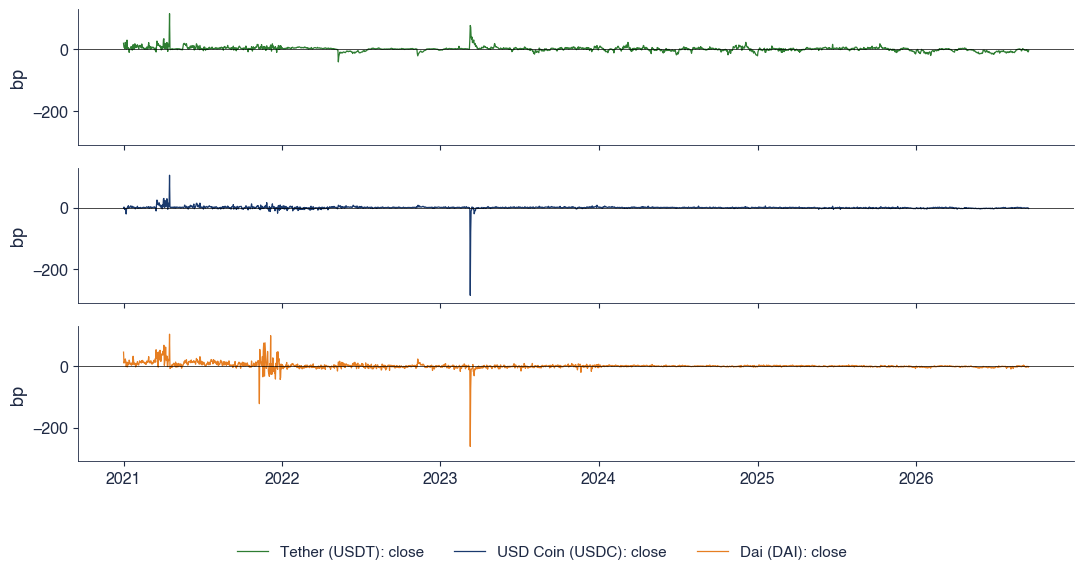

In [31]:
pd.DataFrame(fig_peg(save=False)).T.round(3)

{'usdc': {'low': 0.8774,
  'low_date': '2023-03-11',
  'close_min': 0.9715,
  'close_min_date': '2023-03-11',
  'close_max': 1.0001843997,
  'close_max_date': '2023-03-15',
  'closes': {'2023-03-08': 0.9998693548,
   '2023-03-09': 1.0000077029,
   '2023-03-10': 0.999478547,
   '2023-03-11': 0.9715,
   '2023-03-12': 0.9920691726,
   '2023-03-13': 0.998946756,
   '2023-03-14': 0.9991785646,
   '2023-03-15': 1.0001843997,
   '2023-03-16': 0.9999612189,
   '2023-03-17': 1.0000446277,
   '2023-03-18': 0.9995019398,
   '2023-03-19': 0.9998449095,
   '2023-03-20': 0.9979803872}},
 'dai': {'low': 0.8970032281,
  'low_date': '2023-03-11',
  'close_min': 0.973868652,
  'close_min_date': '2023-03-11',
  'close_max': 1.0004739766,
  'close_max_date': '2023-03-17',
  'closes': {'2023-03-08': 0.9987708271,
   '2023-03-09': 0.9998604337,
   '2023-03-10': 0.9989684466,
   '2023-03-11': 0.973868652,
   '2023-03-12': 0.9925845914,
   '2023-03-13': 0.9989164101,
   '2023-03-14': 0.9989770186,
   '2023-03

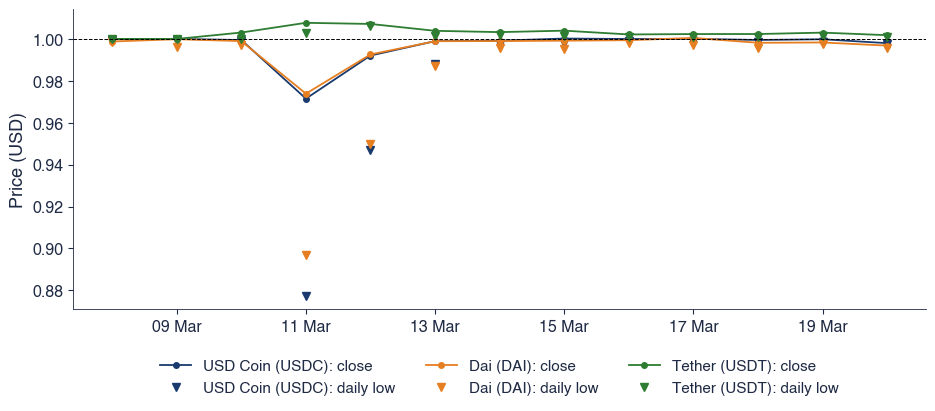

In [32]:
fig_svb(save=False)

{'supply_peak': 18.770471902,
 'supply_peak_date': '2022-05-07',
 'supply_last': 13.692512964,
 'last_date': '2022-05-11',
 'supply_drop': 27.05291036108124,
 'px_pre_min': 0.9995979248741298,
 'px_pre_max': 1.0048688094624807,
 'px_0509': 0.754,
 'px_0513': 0.37,
 'px_0514': 0.129,
 'px_0531': 0.0210424,
 'px_end': 0.00794673,
 'px_end_date': '2022-06-15'}

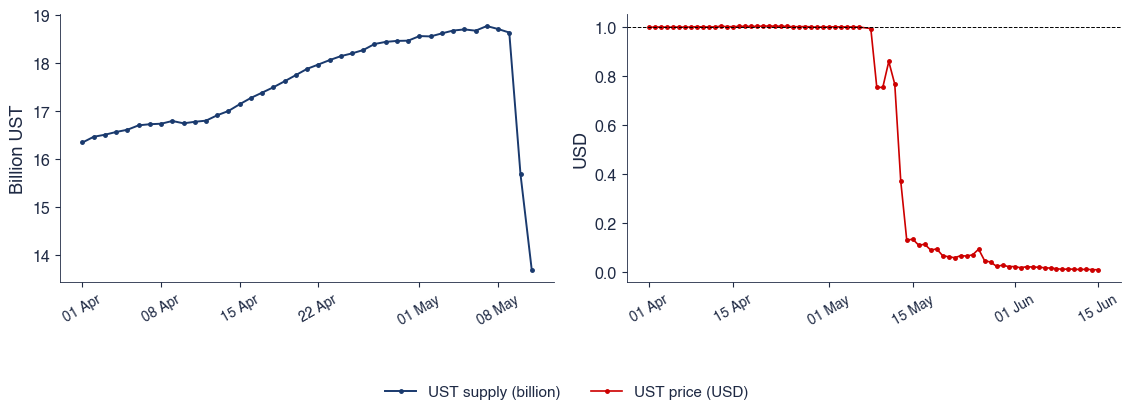

In [33]:
fig_ust(save=False)

## 9. VaR 1% and ES 2.5% of a crypto position

In [34]:
def var_table(names=('btc', 'eth', 'sp500'), W=POSITION):
    """VaR 1% and ES 2.5% (in % and in USD for a position of W) by historical simulation, Normal, Student-t (maximum
    likelihood) on the whole sample and GARCH(1,1)-t for the next day; historical 10-day VaR 1% on overlapping
    10-day returns against the square-root-of-time rule."""
    out = {}
    for k in names:
        r = returns(k)
        x = r.values
        mu, sd = x.mean(), x.std(ddof=1)
        nu, loc, sc = stats.t.fit(x)
        res = garch_fit(r)
        p = res.params
        s1 = float(np.sqrt(res.forecast(horizon=1, reindex=False).variance.values[-1, 0]))
        r10 = np.convolve(x, np.ones(10), mode='valid')
        d = {'n': int(len(x)), 'hs_v': hs_var(x), 'hs_e': hs_es(x),
             'n_v': float(-(mu + sd * stats.norm.ppf(ALPHA_VAR))),
             'n_e': float(-mu + sd * stats.norm.pdf(stats.norm.ppf(ALPHA_ES)) / ALPHA_ES),
             't_v': float(-(loc + sc * stats.t.ppf(ALPHA_VAR, nu))),
             't_e': float(-loc + sc * stats.t.pdf(stats.t.ppf(ALPHA_ES, nu), nu) / ALPHA_ES * (nu + stats.t.ppf(ALPHA_ES, nu) ** 2) / (nu - 1)),
             'nu': float(nu), 'g_sigma': s1, 'g_nu': float(p['nu']),
             'g_v': float(-(p['mu'] + s1 * std_t_q(p['nu'], ALPHA_VAR))), 'g_e': float(-p['mu'] + s1 * std_t_es(p['nu'], ALPHA_ES)),
             'hs10': hs_var(r10), 'sqrt10': float(np.sqrt(10) * hs_var(x)), 'last': r.index[-1].date().isoformat(),
             'mu': float(mu), 'sd': float(sd)}
        for c in ['hs_v', 'hs_e', 'n_v', 'n_e', 't_v', 't_e', 'g_v', 'g_e', 'hs10']:
            d[c + '_usd'] = float(W * (1 - np.exp(-d[c] / 100)))
        out[k] = d
    return out


def backtest_btc(start=BT_START, window=BT_WINDOW, k='btc'):
    """One-day VaR 1% forecasts for Bitcoin since `start`: historical simulation on the last 365 days and
    GARCH(1,1)-t re-estimated every 365 days on all earlier data; exceptions, rate, Kupiec test, exceptions by year
    (another crypto asset with k='eth')."""
    r = returns(k)
    idx = np.where(r.index >= pd.Timestamp(start))[0]
    hs = pd.Series([hs_var(r.values[i - window:i]) for i in idx], index=r.index[idx])
    g = pd.Series(index=r.index[idx], dtype=float)
    for j0 in range(0, len(idx), window):
        i0 = idx[j0]
        am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
        res = am.fit(disp='off', last_obs=r.index[i0], options={'maxiter': 2000})
        f = res.forecast(horizon=1, start=r.index[i0 - 1], reindex=False)
        p = res.params
        q = std_t_q(p['nu'], ALPHA_VAR)
        sig = np.sqrt(f.variance.values[:, 0])
        # forecast made on day i-1 for day i
        fc = pd.Series(-(p['mu'] + sig * q), index=r.index[i0 - 1:])[:-1]
        fc.index = r.index[i0:]
        sl = r.index[idx[j0:j0 + window]]
        g.loc[sl] = fc.loc[sl].values
    out = {'start': r.index[idx[0]].date().isoformat(), 'n': int(len(idx))}
    df = pd.DataFrame({'r': r.iloc[idx], 'HS': hs, 'GARCH-t': g})
    for m in ('HS', 'GARCH-t'):
        hit = df['r'] < -df[m]
        x = int(hit.sum())
        lr, pv = kupiec(x, len(df))
        out[m] = {'x': x, 'rate': float(100 * x / len(df)), 'exp': float(0.01 * len(df)), 'lr': lr, 'p': pv,
                  'year': {str(y): int(v) for y, v in hit.groupby(df.index.year).sum().items()},
                  'mean_var': float(df[m].mean())}
    return out, df


def fig_btc_var(df, save=True):
    """Bitcoin daily returns since 2018 with minus VaR 1% from historical simulation (365 days) and GARCH(1,1)-t."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(df.index, df['r'], color=st.MainBlue, lw=0.5, alpha=0.8, label='Bitcoin daily return (%)')
    ax.plot(df.index, -df['HS'], color=st.Amber, lw=1.3, label='minus VaR 1%: historical simulation, 365 days')
    ax.plot(df.index, -df['GARCH-t'], color=st.IDAred, lw=1.0, label='minus VaR 1%: GARCH(1,1)-t')
    hit = df['r'] < -df['HS']
    ax.scatter(df.index[hit], df['r'][hit], s=14, color=st.Orange, zorder=3, label='Exception of the historical VaR')
    ax.set_ylim(-45, 25)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch14_btc_var')

In [35]:
V = var_table()
pd.DataFrame(V).T[['hs_v', 'hs_e', 'n_v', 'n_e', 't_v', 't_e', 'g_v', 'g_e', 'hs_v_usd', 'hs10', 'sqrt10']].round(2)

,hs_v,hs_e,n_v,n_e,t_v,t_e,g_v,g_e,hs_v_usd,hs10,sqrt10
btc,10.542864,10.844011,7.989714,8.029636,11.064601,13.37019,7.370057,8.10576,10006.131198,29.521406,33.339464
eth,14.285241,14.771463,11.39701,11.454126,15.388696,18.131572,10.946725,12.054469,13311.799768,38.334002,45.173899
sp500,3.256151,3.4985,2.537987,2.550703,3.041818,3.445008,1.779882,1.855994,3203.708799,9.48542,10.296852


In [36]:
bt, df = backtest_btc()
{m: {c: bt[m][c] for c in ['x', 'rate', 'exp', 'lr', 'p']} for m in ['HS', 'GARCH-t']}

{'HS': {'x': 29,
  'rate': 0.9110901665095822,
  'exp': 31.830000000000002,
  'lr': 0.2619629475898364,
  'p': 0.6087747795220853},
 'GARCH-t': {'x': 41,
  'rate': 1.2880929940307886,
  'exp': 31.830000000000002,
  'lr': 2.4460625833966674,
  'p': 0.1178200772868695}}

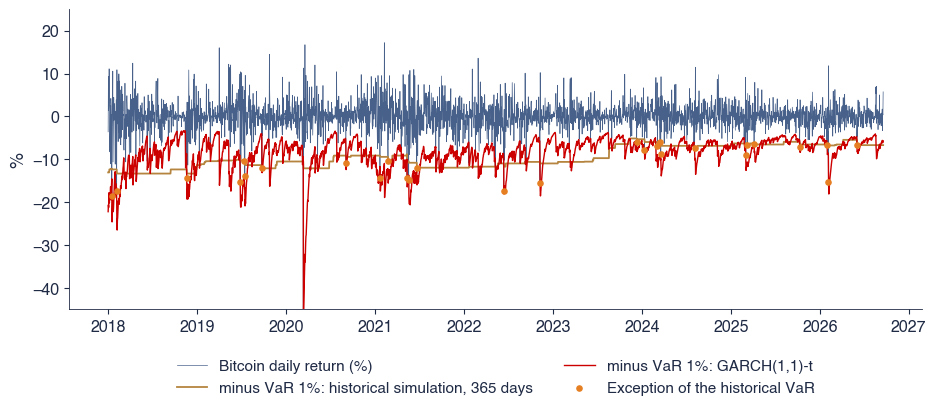

In [37]:
fig_btc_var(df, save=False)

## 10. AI for scientific discovery: do stablecoin flows move crypto prices?

- Open question: does the weekly change of the stablecoin supply predict Bitcoin's next-week return?
- Starter result: same-week and next-week correlation and an HAC regression since 2020.
- Check before trusting any answer, yours or an AI's: 365-day annualisation, prices joined on common days, the same week definition for both series, basis points against percent, no look-ahead in the supply data.

In [38]:
def stablecoin_flows_btc(start='2020-01-01'):
    """Weekly (Sunday to Sunday) log change of the total USD stablecoin supply against Bitcoin's log return in the
    same week and in the next week; OLS with Newey-West standard errors (4 lags)."""
    s = stablecoin_chart()['value'].loc[start:END].resample('W-SUN').last()
    p = close('btc', start).resample('W-SUN').last()
    d = pd.concat([100 * np.log(s).diff(), 100 * np.log(p).diff()], axis=1, keys=['ds', 'r']).dropna()
    d['r_next'] = d['r'].shift(-1)
    d = d.dropna()
    reg = hac_ols(d['r_next'], d['ds'], lags=4)
    return {'n': int(len(d)), 'corr_same': float(d['ds'].corr(d['r'])), 'corr_next': float(d['ds'].corr(d['r_next'])),
            'b': float(reg.params['ds']), 't': float(reg.tvalues['ds']), 'p': float(reg.pvalues['ds']), 'r2': float(reg.rsquared)}

In [39]:
stablecoin_flows_btc()

{'n': 349,
 'corr_same': 0.262409166545784,
 'corr_next': 0.06530572137968145,
 'b': 0.18506366676482663,
 't': 1.1989417764122097,
 'p': 0.23055058595284839,
 'r2': 0.004264837244920994}